In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import pandas as pd

import os
import json
from huggingface_hub import HfApi
from huggingface_hub import upload_folder
import skops.io as sio
from skops import card
import pickle
from datetime import date
sns.set_theme(palette='colorblind')

In [2]:
med_df = pd.read_csv('heart_failure_clinical_records_dataset.csv')

The Heart Failure Clinical Records dataset includes information on 299 patients with 13 clinical features and shows whether each patient died during a follow-up period. Each row represents one patient, and the columns describe measurements such as age, anaemia status, creatinine phosphokinase, diabetes, ejection fraction, high blood pressure, platelet count, serum creatinine, serum sodium, sex, smoking status, and time in days. The target variable, DEATH_EVENT, indicates if the patient died.

The modeling task for this dataset is to use patients’ clinical and demographic information to predict health outcomes related to heart failure. In simpler terms, the goal is to build a model that learns patterns from features like age, blood pressure, kidney function, and heart performance, and uses them to estimate the likelihood that a patient will experience a death event during the follow-up period. Linear regression is a good starting point because it provides clear, interpretable coefficients that show how each feature affects the predicted risk. It is also simple to analyze and serves as a good baseline before testing more complex models.

In [3]:
med_df.head(5)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [4]:
med_df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


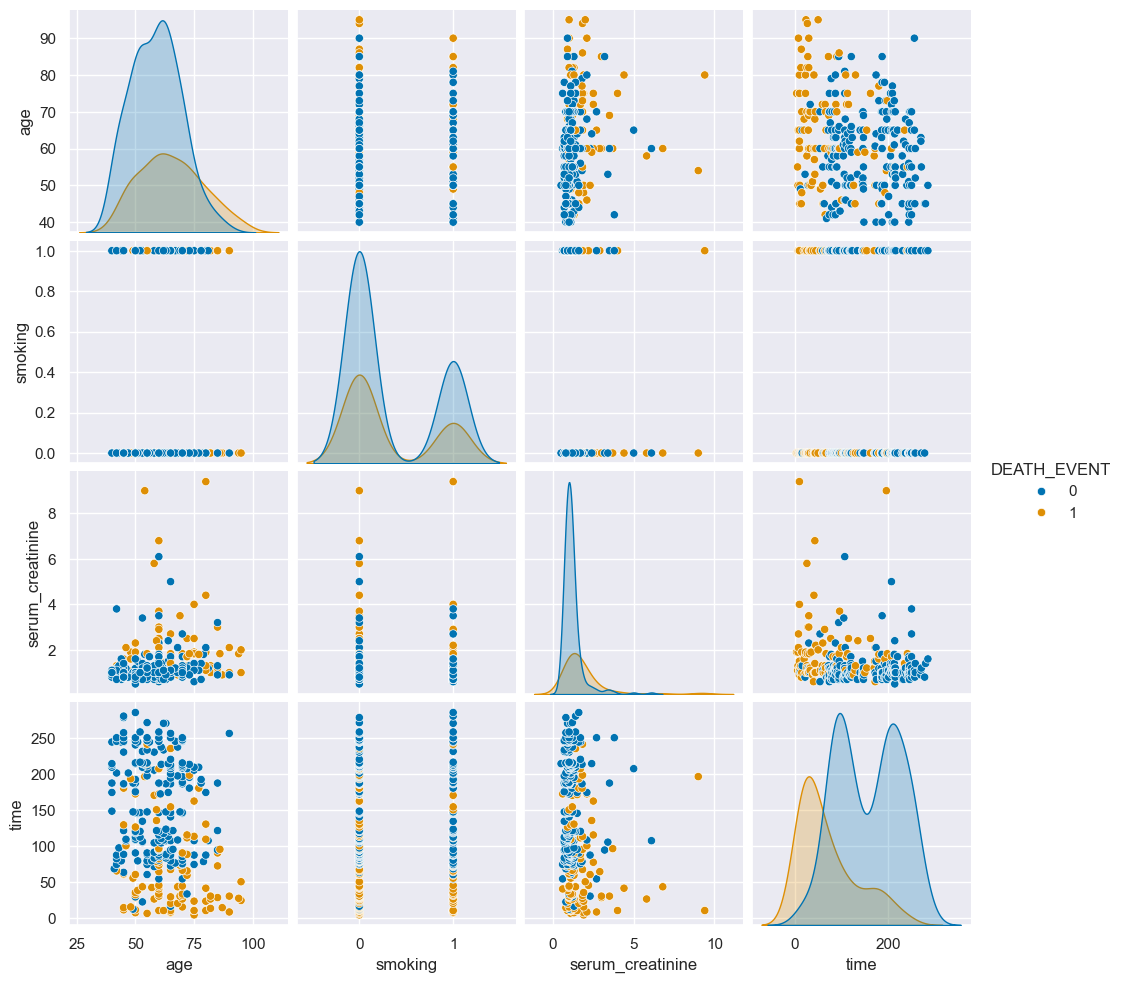

In [5]:
import seaborn as sns
sns.pairplot(med_df[["age", "smoking", "serum_creatinine", "time", "DEATH_EVENT"]], hue="DEATH_EVENT")

Exploratory data analysis shows that ejection fraction, serum creatinine, and age are the strongest predictors of mortality, while other variables such as smoking and diabetes show a lot of overlap between survivors and non-survivors. In this dataset, ejection fraction measures the percentage of blood the left ventricle pumps out with each heartbeat. Lower values mean the heart is pumping less efficiently, which often signals heart failure or damage to the heart muscle. Because of this, patients with low ejection fraction tend to have a much higher risk of death, making it one of the most important predictors in this analysis. Since the dataset is small and unbalanced, the model is expected to perform only moderately well, likely producing more false negatives by predicting survival for some patients who actually die, as there are more survivors overall.

In [6]:
med_X = med_df.drop('DEATH_EVENT', axis=1)
med_y = med_df['DEATH_EVENT']

In [7]:
med_X_train_full, med_X_test, med_y_train_full, med_y_test = train_test_split(
    med_X, med_y, test_size=0.2, random_state=74)

In [8]:
med_X_train, med_X_val, med_y_train, med_y_val = train_test_split(
    med_X_train_full, med_y_train_full, test_size=0.25, random_state=74
)

In [9]:
regr_med = linear_model.LinearRegression()
regr_med.fit(med_X_train, med_y_train)

LinearRegression()

In [10]:
lasso = linear_model.Lasso()
lasso.fit(med_X_train, med_y_train)
lasso.score(med_X_test, med_y_test)

0.27716588635811557

In [11]:
coefs = lasso.coef_
n_coefs = len(coefs) - sum(coefs==0)
coefs

array([ 0.00000000e+00, -0.00000000e+00, -5.77910709e-06,  0.00000000e+00,
       -3.18619539e-03,  0.00000000e+00, -1.98709743e-07,  0.00000000e+00,
       -0.00000000e+00, -0.00000000e+00, -0.00000000e+00, -2.98422880e-03])

In [12]:
lasso = linear_model.Lasso(alpha=.25)
lasso.fit(med_X_train, med_y_train)
lasso.score(med_X_test, med_y_test)

0.36852211958634307

In [13]:
coefs = lasso.coef_
n_coefs = len(coefs) - sum(coefs==0)
coefs

array([ 4.29947017e-03, -0.00000000e+00, -5.93850816e-06,  0.00000000e+00,
       -9.09358095e-03,  0.00000000e+00, -1.29984283e-07,  0.00000000e+00,
       -0.00000000e+00, -0.00000000e+00, -0.00000000e+00, -2.83980272e-03])

In [14]:
lasso = linear_model.Lasso(alpha=.05)
lasso.fit(med_X_train, med_y_train)
lasso.score(med_X_test, med_y_test)

0.39233806352549094

In [15]:
coefs = lasso.coef_
n_coefs = len(coefs) - sum(coefs==0)
coefs

array([ 5.78215923e-03, -0.00000000e+00, -3.83305991e-06,  0.00000000e+00,
       -1.04532997e-02,  0.00000000e+00, -1.13252361e-07,  0.00000000e+00,
       -3.07949094e-03, -0.00000000e+00, -0.00000000e+00, -2.77462113e-03])

Across all three coefficient arrays, most values are zero, and the few nonzero ones are very small. This means that most features have little or no impact on the model’s predictions. The small positive values suggest that increasing those variables slightly raises the predicted risk of death, while the small negative values show a weak protective effect. Since all the coefficients are so small, the model is not finding strong linear relationships in the data. This suggests that the outcome is likely influenced by more complex or nonlinear patterns that a simple linear model cannot capture.

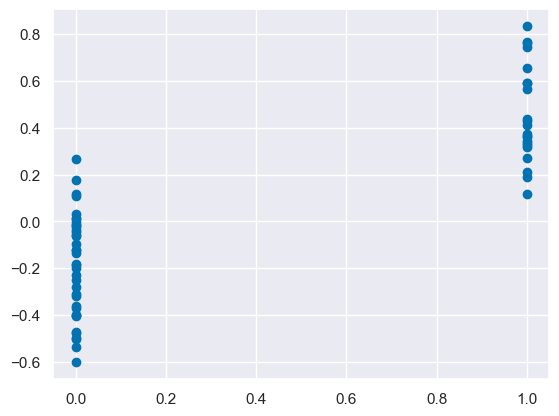

In [16]:
med_y_pred = lasso.predict(med_X_test)
plt.scatter(med_y_test, med_y_test-med_y_pred)

In [17]:
feature_names = med_df.columns

In [18]:
med_residuals_wide = pd.DataFrame(data = med_X_test, columns = feature_names)
med_residuals_wide['y_pred'] = med_y_pred
med_residuals_wide['y_test'] = med_y_test
med_residuals_wide['residual'] = med_y_test - med_y_pred

med_residuals = med_residuals_wide.melt(id_vars = ['residual','y_pred','y_test'],
                        value_vars = feature_names, value_name='feature_value', var_name='feature')
med_residuals.head()

,residual,y_pred,y_test,feature,feature_value
0,-0.096077,0.096077,0,age,90.0
1,0.012987,-0.012987,0,age,40.0
2,0.364189,0.635811,1,age,49.0
3,0.563686,0.436314,1,age,80.0
4,0.115682,0.884318,1,age,80.0


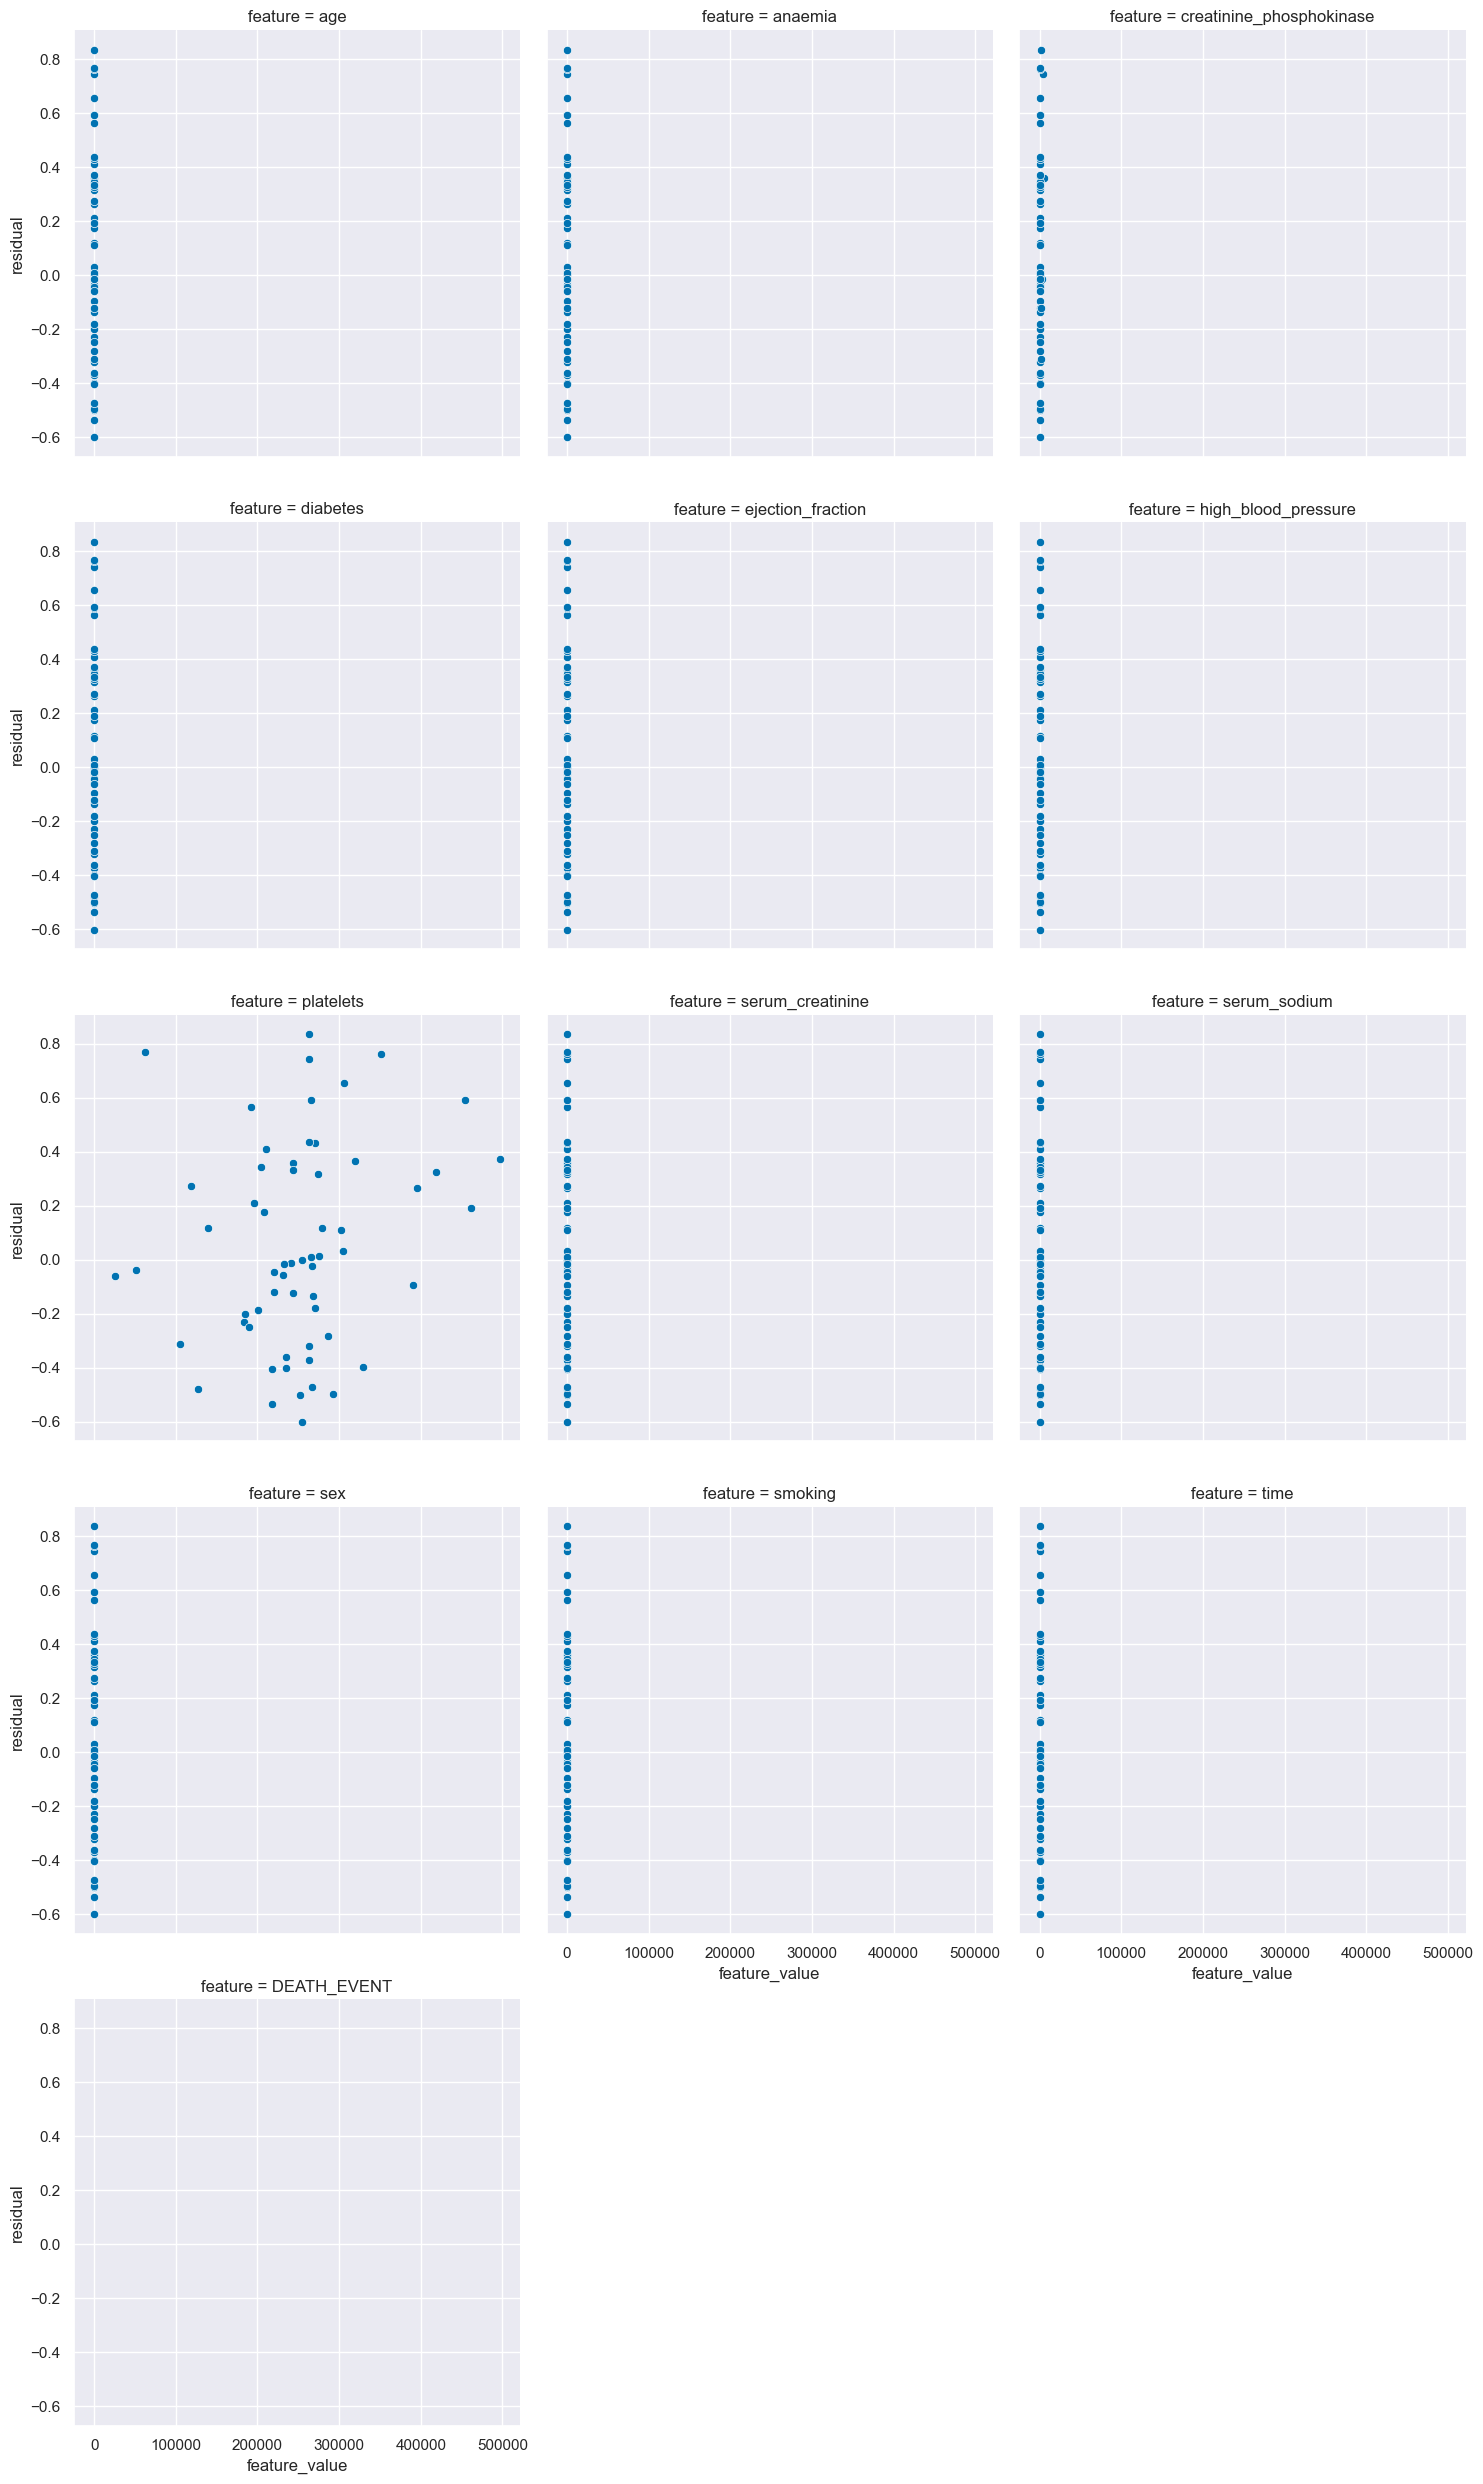

In [19]:
sns.relplot(data = med_residuals, x='feature_value',y = 'residual',
          col='feature',col_wrap=3)

The residuals show the difference between the actual and predicted values. In this model, they are spread out and not centered perfectly around zero, meaning the predictions are not very precise. Some points are predicted too high or too low, especially for patients at the extremes. This suggests the linear model captures general trends but does not fit all cases well. The scattered pattern of residuals also shows that while there is no strong bias, the model misses some of the more complex relationships in the data.

This model is not strong enough to be used in a real medical setting. While it captures general patterns, such as lower ejection fraction and higher serum creatinine being linked to a higher risk of death, the Lasso score (0.392) shows that the model explains only a small portion of the variation in patient outcomes. This means its predictions are not very reliable. I would not trust this model to make real-world clinical decisions because the low Lasso score and scattered residuals show that it often misses important details in the data. A more complex model, such as logistic regression or a tree-based method, could likely perform better by capturing nonlinear relationships and interactions between features. However, the dataset itself is small and limited, which restricts how much any model can learn. This suggests that while machine learning can help identify general trends, this particular task cannot be done accurately with the available data.

To fit the model only on one feature, I chose ejection fraction as the single feature, because the exploratory data analysis showed it had one of the clearest relationships with the outcome, and the earlier regression results confirmed it as one of the most influential predictors of death events. Clinically, ejection fraction represents how well the heart pumps blood, so lower values indicate weaker heart function and a higher risk of death.

In [20]:
med_X = med_df[['ejection_fraction']]
med_y = med_df['DEATH_EVENT']

In [21]:
med_X_train_full, med_X_test, med_y_train_full, med_y_test = train_test_split(
    med_X, med_y, test_size=0.2, random_state=74)

In [22]:
med_X_train, med_X_val, med_y_train, med_y_val = train_test_split(
    med_X_train_full, med_y_train_full, test_size=0.25, random_state=74
)

In [23]:
regr = linear_model.LinearRegression()

In [24]:
regr.__dict__

{'fit_intercept': True, 'copy_X': True, 'n_jobs': None, 'positive': False}

In [25]:
regr.fit(med_X_train, med_y_train)

LinearRegression()

In [26]:
regr.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['ejection_fraction'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([-0.01284247]),
 'rank_': 1,
 'singular_': array([153.08999799]),
 'intercept_': 0.8225638130961954}

In [27]:
med_y_pred = regr.predict(med_X_test)

In [28]:
regr.score(med_X_test, med_y_test)

0.10859139058287526

In [29]:
mean_squared_error(med_y_pred, med_y_test)

0.20700488818686563

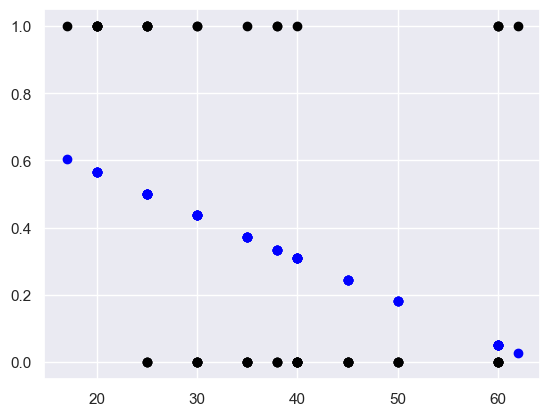

In [30]:
plt.scatter(med_X_test, med_y_test, color='black')
plt.scatter(med_X_test, med_y_pred, color='blue')

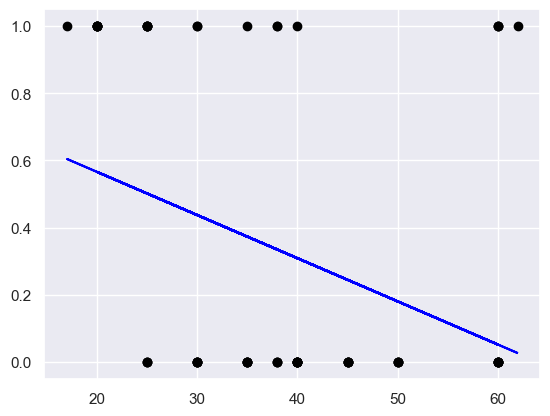

In [31]:
plt.scatter(med_X_test, med_y_test, color='black')
plt.plot(med_X_test, med_y_pred, color='blue')

When the model was trained using just ejection fraction, the scatterplot of predicted versus actual values showed a clear downward trend. As ejection fraction decreased, the predicted likelihood of death increased, which matches both the model’s coefficients and real-world medical understanding. Although the single-feature model is simpler and less precise than the full model, it still demonstrates a meaningful relationship between heart performance and survival. This makes ejection fraction a strong standalone indicator of risk and a logical choice for a simplified regression model.